# Étape 1 : Extraction des Flux RSS

In [ ]:
# %pip install feedparser

In [ ]:
import feedparser
url_alerte = "https://www.cert.ssi.gouv.fr/alerte/feed/"
rss_alerte_feed = feedparser.parse(url_alerte)
for entry in rss_alerte_feed.entries:
    print("Titre :", entry.title)
    print("Description:", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)

url_avis = "https://www.cert.ssi.gouv.fr/avis/feed/"
rss_avis_feed = feedparser.parse(url_avis)
for entry in rss_avis_feed.entries:
    print("Titre :", entry.title)
    print("Description:", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)


# Étape 2 : Extraction des CVE

In [ ]:
from datetime import datetime
import requests
import re


cve_list_avis = []

# liste de dictionnaire pour le dataframe
list_cve = []
#url = "https://www.cert.ssi.gouv.fr/alerte/CERTFR-2024-ALE-001/json/"
for entry in rss_avis_feed.entries:
    link_array = entry.link.split("/")
    # example split :
    #['https:', '', 'www.cert.ssi.gouv.fr', 'avis', 'CERTFR-2026-AVI-0701', '']
    bulletin_name = link_array[4]
    url = "https://www.cert.ssi.gouv.fr/avis/" + bulletin_name +"/json/"
    #print(url)

    response = requests.get(url)
    data = response.json()
    for cve_item in data.get("cves", []):

            cve_id = cve_item.get("name")

            cve_data = {
                "ID ANSSI": bulletin_name,
                "Titre ANSSI": data.get("title"),
                "Type": "Avis",
                "Date": data.get('revisions')[0]['revision_date'],
                "CVE": cve_id,
                "CVSS": None,
                "Base Severity": None,
                "CWE": None,
                "EPSS": None,
                "Lien": cve_item.get("url"),
                "Description": None,
                "Editeur": None,
                "Produit": None,
                "Versions affectées": None
            }

            list_cve.append(cve_data)


    #Extraction des CVE reference dans la clé cves du dict data
    ref_cves=list(data["cves"])
    #attention il s’agit d’une liste des dictionnaires avec name et url comme clés
    # print( "CVE référencés ", ref_cves)
    # Extraction des CVE avec une regex
    cve_pattern = (r"CVE-\d"
                   r""
                   r"{4}-\d{4,7}")
    cve_list_avis.append(list(set(re.findall(cve_pattern, str(data)))))


cve_list_alert = []
for entry in rss_alerte_feed.entries:
    link_array = entry.link.split("/")
    # example split :
    #['https:', '', 'www.cert.ssi.gouv.fr', 'avis', 'CERTFR-2026-AVI-0701', '']
    bulletin_name = link_array[4]
    url = "https://www.cert.ssi.gouv.fr/alerte/" + bulletin_name +"/json/"
    # print(url)

    response = requests.get(url)
    data = response.json()
    for cve_item in data.get("cves", []):
            cve_id = cve_item.get("name")

            cve_data = {
                "ID ANSSI": data.get("reference"),
                "Titre ANSSI": data.get("title"),
                "Type": "Alerte",
                "Date": data.get('revisions')[0]['revision_date'],
                "CVE": cve_id,
                "CVSS": None,
                "Base Severity": None,
                "CWE": None,
                "EPSS": None,
                "Lien": cve_item.get("url"),
                "Description": data.get("description"),
                "Editeur": None,        #
                "Produit": None,
                "Versions affectées": None
            }
            list_cve.append(cve_data)
    #Extraction des CVE reference dans la clé cves du dict data
    ref_cves=list(data["cves"])
    #attention il s’agit d’une liste des dictionnaires avec name et url comme clés
    # print( "CVE référencés ", ref_cves)
    # Extraction des CVE avec une regex
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cve_list_alert.append(list(set(re.findall(cve_pattern, str(data)))))

print(list_cve)


In [ ]:
print("CVE trouvés alerte:", cve_list_alert)
print("CVE trouvés avis", cve_list_avis)

In [ ]:
import itertools

list_cve_id = list(itertools.chain.from_iterable(cve_list_alert)) + list(itertools.chain.from_iterable(cve_list_avis))
print(list_cve_id)

In [ ]:
# Find duplicates
print(len(list_cve_id))
print(len(set(list_cve_id)))

In [ ]:
list_cve_id = list(set(list_cve_id))
print(len(list_cve_id))

# Étape 3 : Enrichissement des CVE

In [ ]:
import os
ids_alertes = os.listdir(r"data.zip/alertes/")
ids_avis = os.listdir(r"data.zip/avis/")


import json
#acceder à un avis
avis_id = "CERTFR-2024-AVI-0012"
with open(r"data.zip/avis/" + avis_id, 'r') as f:
    data = json.load(f)

data
# #acceder à une alerte
# alerte_id = "CERTFR-2024-ALE-011"
# with open(r"alertes/" + alerte_id, 'r') as f:
#     data = json.load(f)
#
#
# #acceder aux info mitre d'un cve
# cve_id = "CVE-2023-46805"
# with open(r"mitre/" + cve_id, 'r') as f:
#     data = json.load(f)
#
# #acceder aux info first d'un cve (epss)
# cve_id = "CVE-2023-46805"
# with open(r"first/" + cve_id, 'r') as f:
#     data = json.load(f)

In [ ]:
"""
READ ME !!!!

Cette cellule met 15 min à terminer. Elle crée un dictionnaire utilisé après.
Ce dictionnaire est déjà présent dans le fichier 'cve_info.json'.
Vous pouvez regarder les cellules suivantes pour le charger
"""
def cellule_not_to_lauch(cve_list):
    cve_info = {}
    for cve_id in cve_list:
        cve_info[cve_id] = {}
        url = (f"https://cveawg.mitre.org/api/cve/{cve_id}")
        response = requests.get(url)
        data = response.json()
        cvss_score = "na"

        # Extraire la description
        try:
            description = data["containers"]["cna"]["descriptions"][0]["value"]
        except:
            description = "na"
            cve_info[cve_id]['cvss_score'] = cvss_score
            cve_info[cve_id]['cwe'] = "na"
            cve_info[cve_id]['products'] = []
            cve_info[cve_id]['description'] = description
            continue

        # Extraire le score CVSS
        # ATTENTION tous les CVE ne contiennent pas nécessairement ce champ, gérez l'exception,
        # ou peut etre au lieu de cvssV3_0 c'est cvssV3_1 ou autre clé
        key = None
        try:
            if list(data["containers"]["cna"]["metrics"][0].keys())[0] == 'format':
                key = list(data["containers"]["cna"]["metrics"][0].keys())[2]
            else:
                key = list(data["containers"]["cna"]["metrics"][0].keys())[0]
        except:
            pass
            # print("no metrics")

        try:
            cvss_score = data["containers"]["cna"]["metrics"][0][key]["baseScore"]
        except Exception:
            pass
            # print("not found")

        cwe = "na"
        cwe_desc = "na"
        try:
            problemtype = data["containers"]["cna"].get("problemTypes", {})
            if problemtype and "descriptions" in problemtype[0]:
                cwe = problemtype[0]["descriptions"][0].get("cweId", "na")
                cwe_desc = problemtype[0]["descriptions"][0].get("description", "na")
        except:
            pass

        # Extraire tous les produits affectés
        # -> liste de dicts {vendor, product, versions}
        products = []
        try:
            affected = data["containers"]["cna"]["affected"]
            for product in affected:
                try:
                    vendor = product["vendor"]
                    product_name = product["product"]
                    versions = [v["version"] for v in product["versions"] if v["status"] == "affected"]
                    products.append({"vendor": vendor, "product": product_name, "versions": versions})
                except:
                    print(f"version error {cve_id}")
        except:
            pass

        cve_info[cve_id]['cvss_score'] = cvss_score
        cve_info[cve_id]['cwe'] = cwe
        # On garde la liste complète des produits affectés
        cve_info[cve_id]['products'] = products
        cve_info[cve_id]['description'] = description

    return cve_info


"""
Ne pas lancer sauf si c'est vraiment nécessaire
"""
cve_info = cellule_not_to_lauch(list_cve_id)

In [ ]:
cve_info

In [ ]:
cve_info_copy = cve_info.copy()

In [ ]:

import json

def save_dict_to_json(data_dic, filename):
    """Saves a dictionary to a JSON file."""
    with open(filename, 'w', encoding='utf-8') as f:
        # indent=4 makes the JSON file human-readable
        json.dump(data_dic, f, indent=4, ensure_ascii=False)
    print(f"Data successfully saved to {filename}")

def load_json_to_dict(filename):
    """Loads a JSON file back into a Python dictionary."""
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

In [ ]:
#save the dictionary to a json to not launch again the cellule above
save_dict_to_json(cve_info, "cve_info.json")

In [ ]:
# Get the cve_info from the json file
cve_info = load_json_to_dict("cve_info.json")

In [ ]:
print(cve_info['CVE-2026-22977'])

In [ ]:
print(list_cve[0])

In [ ]:
for cve in list_cve:
    cve_id = cve['CVE']
    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"

    # Requête GET pour récupérer les données JSON
    response = requests.get(url)
    data = response.json()

    # Extraire le score EPSS
    epss_data = data.get("data", [])
    if epss_data:
        epss_score = epss_data[0]["epss"]
        print(f"CVE : {cve_id}")
        print(f"Score EPSS : {epss_score}")
        cve['EPSS'] = epss_score
    else:
        print(f"Aucun score EPSS trouvé pour {cve_id}")

In [ ]:
# Enrichissement de list_cve avec les infos de cve_info (CVSS, CWE, description, éditeur/produit/versions)
for element in list_cve:
    cve_id = element['CVE']
    try:
        info = cve_info[cve_id]
        element['CVSS'] = info['cvss_score']
        element['CWE'] = info['cwe']
        element['Description'] = info['description']

        products = info.get('products', [])
        if products:
            element['Editeur'] = products[0]['vendor']
            element['Produit'] = products[0]['product']
            element['Versions affectées'] = products[0]['versions']
        else:
            element['Editeur'] = None
            element['Produit'] = None
            element['Versions affectées'] = []
    except Exception:
        print(f'{cve_id} not in the database')

# Consolidation des données

In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame.from_dict(list_cve)
df = df.replace('na', np.nan)
df['EPSS'] = df['EPSS'].astype(float)
df['CVSS'] = df['CVSS'].astype(float)
df['Date'] = pd.to_datetime(df['Date'])
df

In [ ]:
def cvss_to_severity(score):
    if pd.isna(score):
        return np.nan
    if score >= 9:
        return "Critical"
    elif score >= 7:
        return "High"
    elif score >= 4:
        return "Medium"
    else:
        return "Low"

df["Base Severity"] = df["CVSS"].apply(cvss_to_severity)
df

In [ ]:
# si base severity pas là alors CVSS aussi
getBaseSeverity = {"Critical": 9.5, "High": 8, "Medium": 5.5, "Low": 2}

lastWord = df["Description"].str.split(" ").str[-1].str[:-1]
fallback_severity = lastWord.map(getBaseSeverity)

mask = df["Base Severity"].isna()
df.loc[mask, "Base Severity"] = fallback_severity[mask].map({9.5:"Critical", 8:"High", 5.5:"Medium", 2:"Low"})
df.loc[mask, "CVSS"] = df.loc[mask, "CVSS"].fillna(fallback_severity[mask])

In [16]:
df.describe()

,Date,CVSS,EPSS
count,1344,929.000000,1333.000000
mean,2026-05-12 14:54:38.571428,7.394618,0.030027
min,2023-07-17 00:00:00,1.100000,0.000030
25%,2026-06-10 00:00:00,7.000000,0.000210
50%,2026-06-11 00:00:00,7.800000,0.000400
75%,2026-06-12 00:00:00,8.000000,0.000810
max,2026-06-12 00:00:00,10.000000,0.944120
std,NaN,1.563241,0.149951


In [ ]:
df.isnull().sum()

In [ ]:
# On applique le .join ligne par ligne sur la colonne (uniquement si ce sont des listes)
df["Versions affectées"] = df["Versions affectées"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

df

# Export des données consolidées (CSV)

In [ ]:
df.to_csv("cve_consolidated.csv", index=False)
print(f"Export effectué : cve_consolidated.csv ({len(df)} lignes, {len(df.columns)} colonnes)")

In [1]:
#Read from the CSV
import pandas as pd
import numpy as np

df = pd.read_csv('cve_consolidated.csv')
df['Date'] = pd.to_datetime(df['Date'])
df

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Editeur,Produit,Versions affectées
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN,Avis,2026-06-05,CVE-2026-20245,NaN,NaN,CWE-116,0.00356,https://www.cve.org/CVERecord?id=CVE-2026-20245,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50752,7.4,High,CWE-295,0.00031,https://www.cve.org/CVERecord?id=CVE-2026-50752,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50751,NaN,NaN,CWE-287,0.11841,https://www.cve.org/CVERecord?id=CVE-2026-50751,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication,Avis,2026-06-09,CVE-2026-44963,9.4,Critical,CWE-502,0.00586,https://www.cve.org/CVERecord?id=CVE-2026-44963,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09,CVE-2026-8045,7.1,High,CWE-611,0.00057,https://www.cve.org/CVERecord?id=CVE-2026-8045,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,2026-01-30,CVE-2026-1281,9.8,Critical,CWE-94,0.81586,https://www.cve.org/CVERecord?id=CVE-2026-1281,A code injection in Ivanti Endpoint Manager Mo...,Ivanti,Endpoint Manager Mobile,NaN
1340,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2026-20127,NaN,NaN,CWE-287,0.58950,https://www.cve.org/CVERecord?id=CVE-2026-20127,A vulnerability in the peering authentication ...,Cisco,Cisco Catalyst SD-WAN Manager,"20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20...."
1341,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2022-20775,NaN,NaN,CWE-25,0.00385,https://www.cve.org/CVERecord?id=CVE-2022-20775,A vulnerability in the CLI of Cisco SD-WAN Sof...,Cisco,Cisco Catalyst SD-WAN,"18.3.1, 19.2.1, 17.2.4, 19.3.0, 18.3.0, 18.3.4..."
1342,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,Alerte,2026-03-31,CVE-2025-53521,9.8,Critical,CWE-121,0.08766,https://www.cve.org/CVERecord?id=CVE-2025-53521,When a BIG-IP APM access policy is configured ...,F5,BIG-IP,"17.5.0, 17.1.0, 16.1.0, 15.1.0"


# Interprétation et visualisation

In [2]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

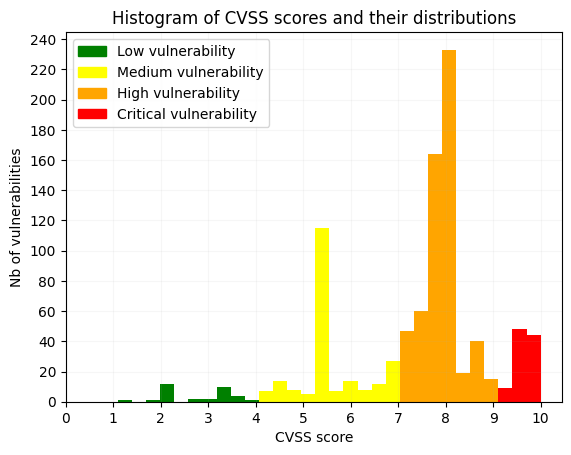

In [3]:
"""
Histogramme des scores CVSS :

Distribution des vulnérabilités
selon leur niveau de gravité (critique, élevée, moyenne)
"""

n, bins, patches = plt.hist(df["CVSS"], bins = 30)
for patch in patches:
    value = patch.get_x()
    if value < 4: patch.set_facecolor('green')
    elif value < 7: patch.set_facecolor('yellow')
    elif value < 9: patch.set_facecolor('orange')
    else: patch.set_facecolor('red')

green_patch = mpatches.Patch(color='green', label='Low vulnerability')
yellow_patch = mpatches.Patch(color='yellow', label='Medium vulnerability')
orange_patch = mpatches.Patch(color='orange', label='High vulnerability')
red_patch = mpatches.Patch(color='red', label='Critical vulnerability')

plt.title("Histogram of CVSS scores and their distributions")
plt.xlabel("CVSS score")
plt.ylabel("Nb of vulnerabilities")
plt.legend(handles=[green_patch, yellow_patch, orange_patch, red_patch])
plt.xticks(np.arange(0, 11, 1))
plt.yticks(np.arange(0, 250, 20))
plt.grid(True, alpha=0.1)



plt.show()

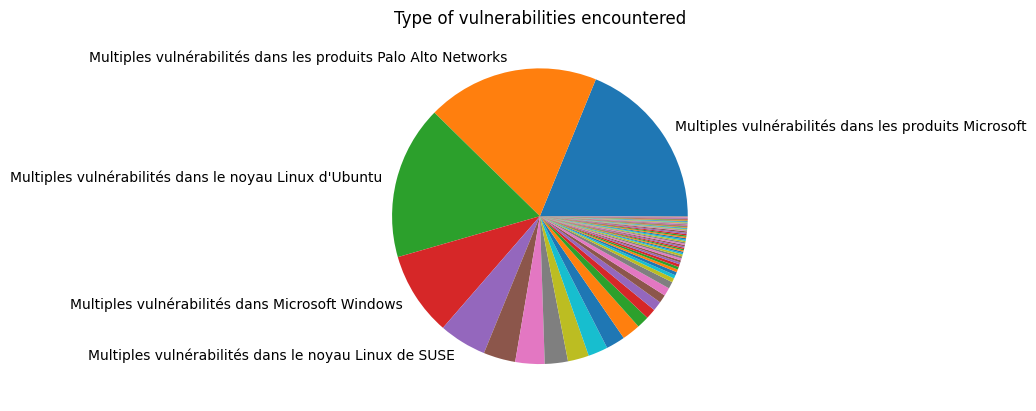

In [4]:
"""
Diagramme circulaire des types de vulnérabilités (CWE) rencontrées
"""

countsANSSI = df["Titre ANSSI"].value_counts()

labelsANSSI = countsANSSI.index.tolist()
sizesANSSI = countsANSSI.values.tolist()

for i in range(len(labelsANSSI)):
    if sizesANSSI[i] < 50:
            labelsANSSI[i] = ""

plt.pie(sizesANSSI, labels=labelsANSSI)
plt.title("Type of vulnerabilities encountered")

plt.show()

Text(0.5, 1.0, 'Editor affected by vulnerabilities')

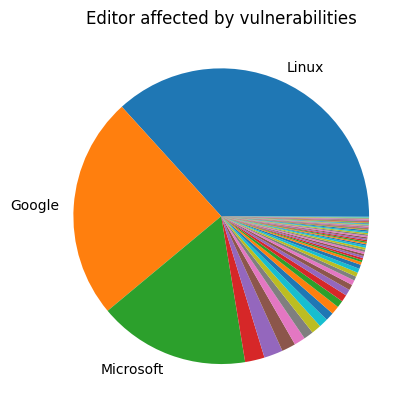

In [5]:
"""
Diagramme circulaire des editeurs affectés par des vulnérabilités
"""

countsEditeur = df["Editeur"].value_counts()

labelsEditeur = countsEditeur.index.tolist()
sizesEditeur = countsEditeur.values.tolist()

for i in range(len(labelsEditeur)):
    if sizesEditeur[i] < 50:
        labelsEditeur[i] = ""

plt.pie(sizesEditeur, labels=labelsEditeur)
plt.title("Editor affected by vulnerabilities")

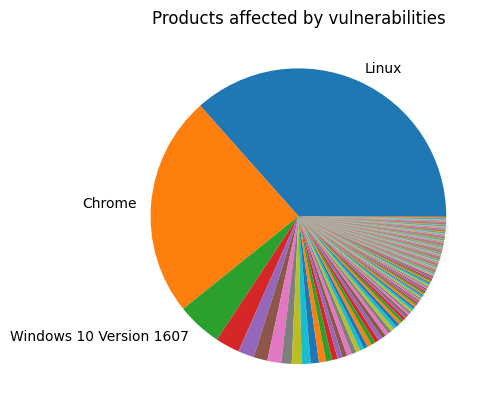

In [6]:
"""
Diagramme circulaire des Produit affectés par des vulnérabilités
"""

countsProduit = df["Produit"].value_counts()

labelsProduit = countsProduit.index.tolist()
sizesProduit = countsProduit.values.tolist()

for i in range(len(labelsProduit)):
    if sizesProduit[i] < 50:
        labelsProduit[i] = ""

plt.pie(sizesProduit, labels=labelsProduit)
plt.title("Products affected by vulnerabilities")

plt.show()

[2023, 2024, 2025, 2026]


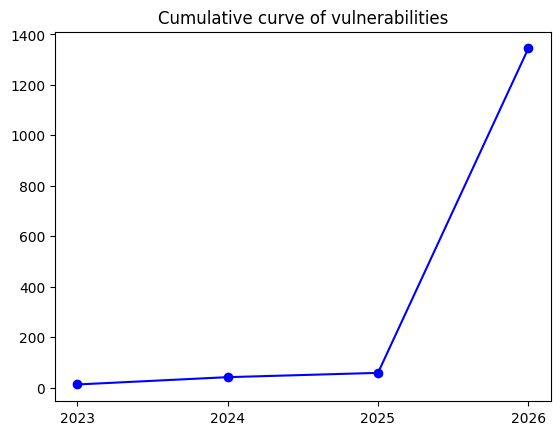

In [9]:
"""
Courbe cumulative des vulnérabilités en fonction du temps
"""

# lastWord = df["Description"].str.split(" ").str[-1].str[:-1]
# df["Base Severity"] = lastWord.map(getBaseSeverity)
# df["CVSS"] = df["CVSS"].fillna(df["Base Severity"])
# df

countsDate = df["Date"].dt.year.value_counts().sort_index()

labelsDate = countsDate.index.tolist()
sizesDate = np.cumsum(countsDate.values.tolist())

print(labelsDate)

plt.plot(labelsDate, sizesDate, "ob-")
plt.xticks(np.arange(min(labelsDate), max(labelsDate)+1, 1))
plt.title("Cumulative curve of vulnerabilities")

plt.show()

In [14]:
df

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Editeur,Produit,Versions affectées
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN,Avis,2026-06-05,CVE-2026-20245,NaN,NaN,CWE-116,0.00356,https://www.cve.org/CVERecord?id=CVE-2026-20245,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50752,7.4,High,CWE-295,0.00031,https://www.cve.org/CVERecord?id=CVE-2026-50752,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50751,NaN,NaN,CWE-287,0.11841,https://www.cve.org/CVERecord?id=CVE-2026-50751,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication,Avis,2026-06-09,CVE-2026-44963,9.4,Critical,CWE-502,0.00586,https://www.cve.org/CVERecord?id=CVE-2026-44963,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09,CVE-2026-8045,7.1,High,CWE-611,0.00057,https://www.cve.org/CVERecord?id=CVE-2026-8045,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,2026-01-30,CVE-2026-1281,9.8,Critical,CWE-94,0.81586,https://www.cve.org/CVERecord?id=CVE-2026-1281,A code injection in Ivanti Endpoint Manager Mo...,Ivanti,Endpoint Manager Mobile,NaN
1340,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2026-20127,NaN,NaN,CWE-287,0.58950,https://www.cve.org/CVERecord?id=CVE-2026-20127,A vulnerability in the peering authentication ...,Cisco,Cisco Catalyst SD-WAN Manager,"20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20...."
1341,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2022-20775,NaN,NaN,CWE-25,0.00385,https://www.cve.org/CVERecord?id=CVE-2022-20775,A vulnerability in the CLI of Cisco SD-WAN Sof...,Cisco,Cisco Catalyst SD-WAN,"18.3.1, 19.2.1, 17.2.4, 19.3.0, 18.3.0, 18.3.4..."
1342,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,Alerte,2026-03-31,CVE-2025-53521,9.8,Critical,CWE-121,0.08766,https://www.cve.org/CVERecord?id=CVE-2025-53521,When a BIG-IP APM access policy is configured ...,F5,BIG-IP,"17.5.0, 17.1.0, 16.1.0, 15.1.0"


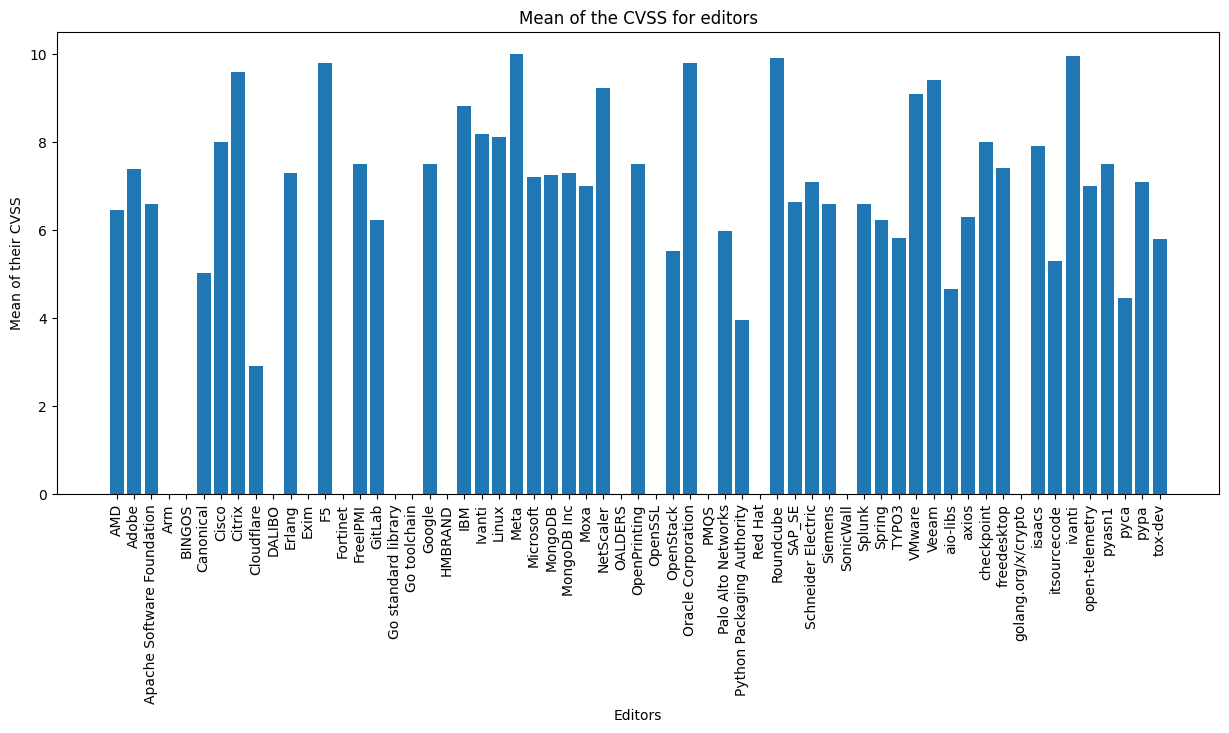

In [32]:
counts = df.groupby(['Editeur']).CVSS.mean()
plt.subplots(figsize=(15, 6))
plt.bar(counts.index, counts.values)
plt.tick_params('x', rotation=90)
plt.xlabel("Editors")
plt.ylabel('Mean of their CVSS')
plt.title('Mean of the CVSS for editors')
plt.show()

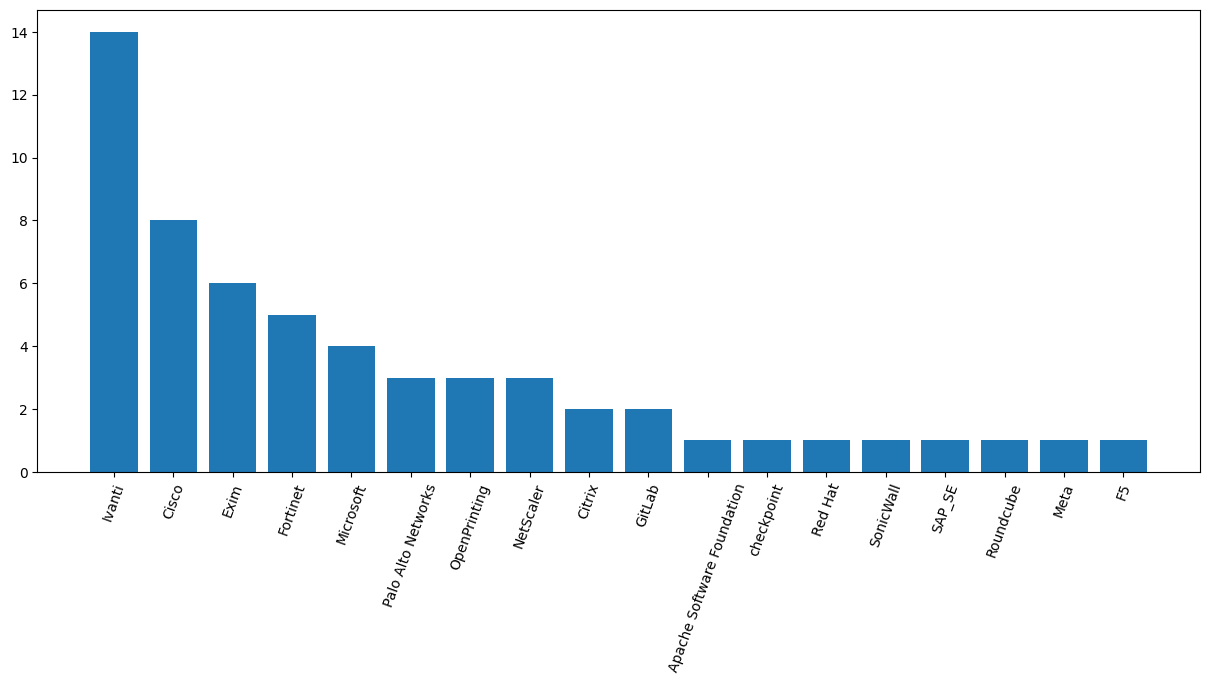

In [12]:
counts = df.Editeur[df["ID ANSSI"].str.contains('ALE')].value_counts()
# plt.bar(counts.index, counts.values)
plt.subplots(figsize=(15, 6))
plt.bar(counts.index, counts.values)
plt.tick_params('x', rotation=70)

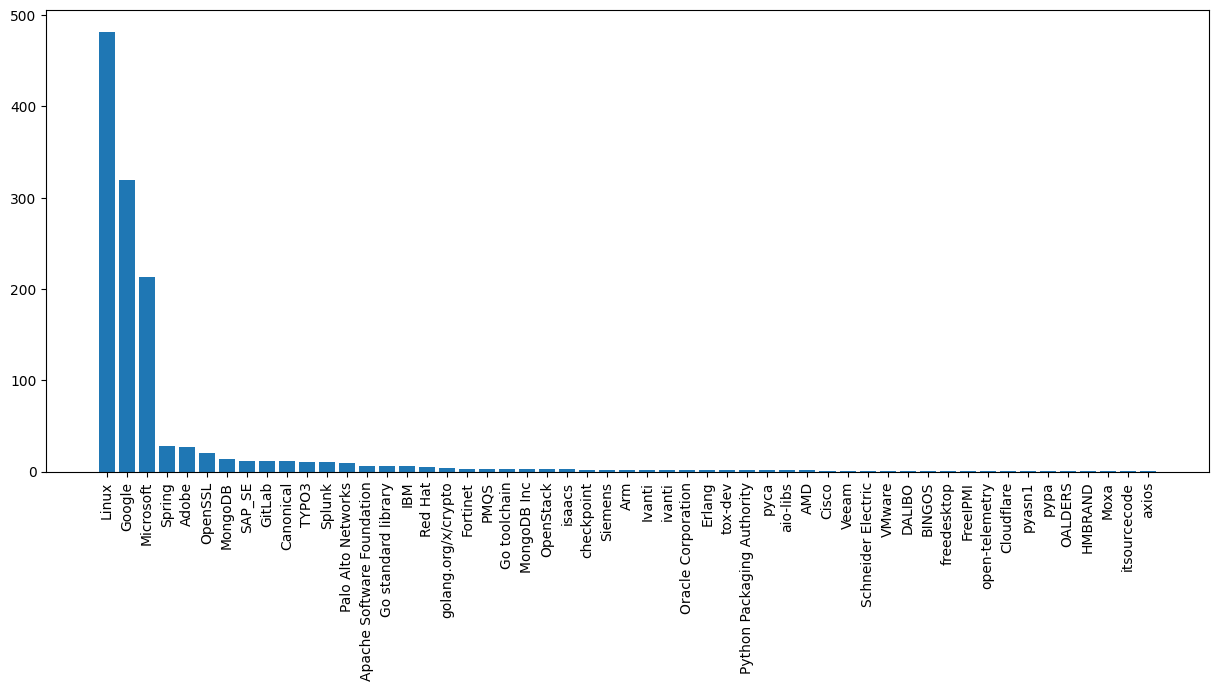

In [13]:
counts = df.Editeur[df["ID ANSSI"].str.contains('AVI')].value_counts()
# plt.bar(counts.index, counts.values)
plt.subplots(figsize=(15, 6))
plt.bar(counts.index, counts.values)

plt.tick_params('x', rotation=90)

# Models

In [2]:
# rappelle du dataframe
df

,ID ANSSI,Titre ANSSI,Type,Date,CVE,CVSS,Base Severity,CWE,EPSS,Lien,Description,Editeur,Produit,Versions affectées
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN,Avis,2026-06-05,CVE-2026-20245,NaN,NaN,CWE-116,0.00356,https://www.cve.org/CVERecord?id=CVE-2026-20245,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50752,7.4,High,CWE-295,0.00031,https://www.cve.org/CVERecord?id=CVE-2026-50752,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Point,Avis,2026-06-09,CVE-2026-50751,NaN,NaN,CWE-287,0.11841,https://www.cve.org/CVERecord?id=CVE-2026-50751,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication,Avis,2026-06-09,CVE-2026-44963,9.4,Critical,CWE-502,0.00586,https://www.cve.org/CVERecord?id=CVE-2026-44963,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09,CVE-2026-8045,7.1,High,CWE-611,0.00057,https://www.cve.org/CVERecord?id=CVE-2026-8045,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,2026-01-30,CVE-2026-1281,9.8,Critical,CWE-94,0.81586,https://www.cve.org/CVERecord?id=CVE-2026-1281,A code injection in Ivanti Endpoint Manager Mo...,Ivanti,Endpoint Manager Mobile,NaN
1340,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2026-20127,NaN,NaN,CWE-287,0.58950,https://www.cve.org/CVERecord?id=CVE-2026-20127,A vulnerability in the peering authentication ...,Cisco,Cisco Catalyst SD-WAN Manager,"20.1.12, 19.2.1, 18.4.4, 18.4.5, 20.1.1.1, 20...."
1341,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,2026-02-25,CVE-2022-20775,NaN,NaN,CWE-25,0.00385,https://www.cve.org/CVERecord?id=CVE-2022-20775,A vulnerability in the CLI of Cisco SD-WAN Sof...,Cisco,Cisco Catalyst SD-WAN,"18.3.1, 19.2.1, 17.2.4, 19.3.0, 18.3.0, 18.3.4..."
1342,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,Alerte,2026-03-31,CVE-2025-53521,9.8,Critical,CWE-121,0.08766,https://www.cve.org/CVERecord?id=CVE-2025-53521,When a BIG-IP APM access policy is configured ...,F5,BIG-IP,"17.5.0, 17.1.0, 16.1.0, 15.1.0"


The point of this model will be to predict the title of the ANSSI

Let us drop the few unneeded columns before building the model. We don't need :
- the ID
- the dates (We don't want to group 2025 problems together and 2026 problems together. The date for us is not a factor)
- The base severity which is in reality just the CVSS
- The links
- The versions

In [3]:
df_dropped_useless = df.drop(['ID ANSSI', 'Date', 'Base Severity', 'Lien', 'Versions affectées'], axis = 1)
df_dropped_useless

,Titre ANSSI,Type,CVE,CVSS,CWE,EPSS,Description,Editeur,Produit
0,Vulnérabilité dans Cisco Catalyst SD-WAN,Avis,CVE-2026-20245,NaN,CWE-116,0.00356,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller
1,Multiples vulnérabilités dans les VPN Check Point,Avis,CVE-2026-50752,7.4,CWE-295,0.00031,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway
2,Multiples vulnérabilités dans les VPN Check Point,Avis,CVE-2026-50751,NaN,CWE-287,0.11841,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway
3,Vulnérabilité dans Veeam Backup & Replication,Avis,CVE-2026-44963,9.4,CWE-502,0.00586,A vulnerability allowing remote code execution...,Veeam,Backup and Replication
4,Vulnérabilité dans les produits Schneider Elec...,Avis,CVE-2026-8045,7.1,CWE-611,0.00057,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert
...,...,...,...,...,...,...,...,...,...
1339,[MàJ] Multiples vulnérabilités dans Ivanti End...,Alerte,CVE-2026-1281,9.8,CWE-94,0.81586,A code injection in Ivanti Endpoint Manager Mo...,Ivanti,Endpoint Manager Mobile
1340,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,CVE-2026-20127,NaN,CWE-287,0.58950,A vulnerability in the peering authentication ...,Cisco,Cisco Catalyst SD-WAN Manager
1341,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN,Alerte,CVE-2022-20775,NaN,CWE-25,0.00385,A vulnerability in the CLI of Cisco SD-WAN Sof...,Cisco,Cisco Catalyst SD-WAN
1342,Vulnérabilité dans F5 BIG-IP Access Policy Man...,Alerte,CVE-2025-53521,9.8,CWE-121,0.08766,When a BIG-IP APM access policy is configured ...,F5,BIG-IP


Nous allons séparer train et test pour tester l'efficacité de notre model plus tard

In [20]:
df_dropped_useless.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Titre ANSSI  1344 non-null   str    
 1   Type         1344 non-null   str    
 2   CVE          1344 non-null   str    
 3   CVSS         929 non-null    float64
 4   CWE          759 non-null    str    
 5   EPSS         1333 non-null   float64
 6   Description  1333 non-null   str    
 7   Editeur      1312 non-null   str    
 8   Produit      1318 non-null   str    
dtypes: float64(2), str(7)
memory usage: 94.6 KB


On remarque des valeurs null dans le tableau, sachant qu'elle sont plutôt random, on va juste enlever les lignes ayant des valeurs null

In [21]:
df_dropped_useless = df_dropped_useless.dropna()

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test= train_test_split(df_dropped_useless, test_size=0.33, random_state=42)

In [23]:
X_train

,Titre ANSSI,Type,CVE,CVSS,CWE,EPSS,Description,Editeur,Produit
275,Multiples vulnérabilités dans Microsoft Windows,Avis,CVE-2026-45601,7.0,CWE-362,0.00049,Use after free in Windows Ancillary Function D...,Microsoft,Windows 10 Version 1607
929,Multiples vulnérabilités dans Google Chrome,Avis,CVE-2026-12033,8.0,CWE-125,0.00026,Out of bounds read in VideoCapture in Google C...,Google,Chrome
1321,[MàJ] Vulnérabilité dans les produits Ivanti,Alerte,CVE-2025-0282,9.0,CWE-121,0.94129,A stack-based buffer overflow in Ivanti Connec...,Ivanti,Connect Secure
552,Multiples vulnérabilités dans GitLab,Avis,CVE-2026-8589,7.3,CWE-79,0.00073,GitLab has remediated an issue in GitLab EE af...,GitLab,GitLab
125,Multiples vulnérabilités dans Microsoft Edge,Avis,CVE-2026-11080,5.5,CWE-416,0.00067,Use after free in WebView in Google Chrome on ...,Google,Chrome
...,...,...,...,...,...,...,...,...,...
102,Multiples vulnérabilités dans les produits Ivanti,Avis,CVE-2026-10520,10.0,CWE-78,0.42699,An OS Command Injection vulnerability in Ivant...,ivanti,Sentry
158,Multiples vulnérabilités dans Microsoft Office,Avis,CVE-2026-45645,7.8,CWE-822,0.00079,Heap-based buffer overflow in Microsoft Office...,Microsoft,Microsoft 365 Apps for Enterprise
353,Multiples vulnérabilités dans les produits Mic...,Avis,CVE-2026-48560,5.4,CWE-502,0.00263,Improper neutralization of input during web pa...,Microsoft,Microsoft SharePoint Enterprise Server 2016
692,Multiples vulnérabilités dans les produits Pal...,Avis,CVE-2026-9113,8.0,CWE-125,0.00027,Out of bounds read in GPU in Google Chrome on ...,Google,Chrome


In [24]:
X_test

,Titre ANSSI,Type,CVE,CVSS,CWE,EPSS,Description,Editeur,Produit
1277,Multiples vulnérabilités dans les produits IBM,Avis,CVE-2026-26996,8.7,CWE-1333,0.00026,minimatch is a minimal matching utility for co...,isaacs,minimatch
570,Multiples vulnérabilités dans les produits Pal...,Avis,CVE-2026-9952,8.0,CWE-416,0.00123,Use after free in WebAudio in Google Chrome pr...,Google,Chrome
93,Multiples vulnérabilités dans Typo3,Avis,CVE-2026-49738,2.1,CWE-22,0.00032,The path allowance check in GeneralUtility::is...,TYPO3,TYPO3 CMS
606,Multiples vulnérabilités dans les produits Pal...,Avis,CVE-2026-9893,9.5,CWE-416,0.00118,Use after free in Skia in Google Chrome prior ...,Google,Chrome
153,Multiples vulnérabilités dans Microsoft Edge,Avis,CVE-2026-11035,5.5,CWE-20,0.00008,Inappropriate implementation in Custom Tabs in...,Google,Chrome
...,...,...,...,...,...,...,...,...,...
281,Multiples vulnérabilités dans Microsoft Windows,Avis,CVE-2026-50507,6.8,CWE-306,0.00099,Protection mechanism failure in Windows BitLoc...,Microsoft,Windows 10 Version 1607
740,Multiples vulnérabilités dans les produits Pal...,Avis,CVE-2026-9874,9.5,CWE-416,0.00073,Use after free in Dawn in Google Chrome prior ...,Google,Chrome
12,Multiples vulnérabilités dans les produits SAP,Avis,CVE-2026-44754,6.6,CWE-862,0.00035,The Remote Function Call (RFC) modules of the ...,SAP_SE,ODP Data Replication APIs
47,Multiples vulnérabilités dans les produits Spring,Avis,CVE-2026-41729,8.1,CWE-917,0.00032,Spring Data REST is vulnerable to SpEL express...,Spring,Spring Data REST


Dans le futur, nous aurons une ligne sans titre et le but sera de le deviner, nous allons donc enlever les titres pour les garder de côté

In [25]:
titles = X_train['Titre ANSSI']
X_train.drop(['Titre ANSSI'], axis=1, inplace=True)

Nous allons donc maintenant encoder les différents strings

Nous effectuons un one hot encoding pour type, CVE, CWE, Editeur et produit

Et nous utilisons un sentenceTransformer pour description car il s'agit d'un texte qui peut être long

In [39]:
from sklearn.preprocessing import OneHotEncoder
# type, CV, CWE, Editeur et produit
encoder = OneHotEncoder(handle_unknown='ignore')
column_to_encode = ['Type', 'CVE', 'CWE', 'Editeur', 'Produit']
encoded_data = encoder.fit_transform(X_train[column_to_encode])
encoded_df_no_description = pd.DataFrame(
    encoded_data.toarray(),
    columns=encoder.get_feature_names_out(column_to_encode),
    index=X_train.index
)
encoded_df_no_description

,Type_Alerte,Type_Avis,CVE_CVE-2023-20585,CVE_CVE-2023-4966,CVE_CVE-2024-0012,CVE_CVE-2024-0402,CVE_CVE-2024-20359,CVE_CVE-2024-24919,CVE_CVE-2024-3400,CVE_CVE-2024-47076,...,Produit_axios,Produit_cups-browsed,Produit_filelock,Produit_libcupsfilters,Produit_libinput,Produit_minimatch,Produit_opentelemetry-go,Produit_pip,Produit_pyopenssl,Produit_wheel
275,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
929,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1321,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
552,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
125,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
158,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
353,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
692,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X_descriptions = model.encode(X_train['Description'].fillna('').tolist(), show_progress_bar=True)
X_descriptions

Batches: 100%|██████████| 15/15 [00:12<00:00,  1.19it/s]


array([[ 0.11584814,  0.0568981 , -0.38390788, ...,  0.34344074,
         0.00813644,  0.08200198],
       [-0.14138483, -0.09427299, -0.3760167 , ...,  0.33373734,
         0.09429355,  0.08997942],
       [-0.12372138, -0.02484169, -0.38785923, ...,  0.2988085 ,
         0.03864961,  0.17889324],
       ...,
       [-0.06209772, -0.26831642, -0.24813673, ...,  0.3513284 ,
         0.15833499,  0.03606366],
       [-0.04738854, -0.04476801, -0.42364383, ...,  0.2362493 ,
        -0.10299985,  0.11078875],
       [ 0.15114649, -0.15231313, -0.46627745, ...,  0.04317013,
         0.31865612,  0.09345957]], shape=(454, 384), dtype=float32)

In [48]:
X_descriptions = pd.DataFrame(X_descriptions, index=X_train.index)
X_descriptions

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
275,0.115848,0.056898,-0.383908,0.086099,-0.090399,0.036958,0.131482,0.144507,-0.180196,0.143741,...,-0.057199,0.132210,0.318653,-0.352658,0.137411,0.288794,-0.123418,0.343441,0.008136,0.082002
929,-0.141385,-0.094273,-0.376017,-0.142145,0.069329,-0.261433,-0.146622,0.261993,0.251058,0.007541,...,0.162418,-0.022929,0.156411,-0.307287,-0.040295,0.546218,-0.061174,0.333737,0.094294,0.089979
1321,-0.123721,-0.024842,-0.387859,0.026589,-0.066608,0.070601,-0.194680,0.069550,0.083170,-0.190256,...,0.026642,-0.305575,-0.151921,-0.219603,0.122547,0.089428,-0.140981,0.298808,0.038650,0.178893
552,-0.234505,-0.077806,-0.016550,0.146078,-0.120772,-0.147515,-0.018599,-0.053829,0.108947,0.077044,...,-0.030428,0.031937,0.164154,-0.019058,0.196587,0.105187,-0.319974,0.249832,-0.166559,-0.010132
125,-0.304574,-0.052919,-0.293419,-0.138852,0.082283,-0.129417,-0.214833,0.275627,0.027921,0.063945,...,0.086567,-0.007570,0.348061,-0.169300,0.029743,0.580063,0.189689,0.059905,0.148631,0.183499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,-0.111170,-0.152087,-0.173080,-0.100967,-0.181603,-0.072341,-0.160534,0.245916,0.152865,-0.034710,...,0.054695,-0.094968,0.136029,-0.306521,0.022369,0.164904,-0.271704,0.225414,-0.163761,0.036236
158,0.152312,-0.133543,-0.491783,-0.307638,0.070532,-0.217235,-0.178032,0.002909,0.022767,0.185628,...,-0.043025,0.029940,0.202700,-0.529153,0.366115,0.623337,-0.476468,0.029100,0.336621,0.074699
353,-0.062098,-0.268316,-0.248137,-0.194121,0.051133,-0.061832,-0.097132,-0.320719,0.041063,0.172909,...,0.002894,0.115674,0.411030,-0.343480,0.390945,0.574943,-0.153798,0.351328,0.158335,0.036064
692,-0.047389,-0.044768,-0.423644,-0.050616,-0.092249,-0.145717,-0.110743,0.298143,0.233525,-0.071365,...,0.037633,-0.017668,0.266071,-0.357265,-0.209530,0.512087,0.042459,0.236249,-0.103000,0.110789


In [49]:
encoded_df = pd.concat(
    [X_train.drop(columns=column_to_encode).drop(['Description'], axis=1), encoded_df_no_description, X_descriptions],
    axis=1
)
encoded_df

,CVSS,EPSS,Type_Alerte,Type_Avis,CVE_CVE-2023-20585,CVE_CVE-2023-4966,CVE_CVE-2024-0012,CVE_CVE-2024-0402,CVE_CVE-2024-20359,CVE_CVE-2024-24919,...,374,375,376,377,378,379,380,381,382,383
275,7.0,0.00049,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.057199,0.132210,0.318653,-0.352658,0.137411,0.288794,-0.123418,0.343441,0.008136,0.082002
929,8.0,0.00026,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.162418,-0.022929,0.156411,-0.307287,-0.040295,0.546218,-0.061174,0.333737,0.094294,0.089979
1321,9.0,0.94129,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.026642,-0.305575,-0.151921,-0.219603,0.122547,0.089428,-0.140981,0.298808,0.038650,0.178893
552,7.3,0.00073,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.030428,0.031937,0.164154,-0.019058,0.196587,0.105187,-0.319974,0.249832,-0.166559,-0.010132
125,5.5,0.00067,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.086567,-0.007570,0.348061,-0.169300,0.029743,0.580063,0.189689,0.059905,0.148631,0.183499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,10.0,0.42699,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.054695,-0.094968,0.136029,-0.306521,0.022369,0.164904,-0.271704,0.225414,-0.163761,0.036236
158,7.8,0.00079,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.043025,0.029940,0.202700,-0.529153,0.366115,0.623337,-0.476468,0.029100,0.336621,0.074699
353,5.4,0.00263,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002894,0.115674,0.411030,-0.343480,0.390945,0.574943,-0.153798,0.351328,0.158335,0.036064
692,8.0,0.00027,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.037633,-0.017668,0.266071,-0.357265,-0.209530,0.512087,0.042459,0.236249,-0.103000,0.110789


On a maintenant un dataframe encodé, on va importer l'algorithme de K-means pour faire un apprentissage non supervisé

In [50]:
#putting the name of the columns as stirngs and not int
encoded_df.columns = encoded_df.columns.astype(str)

Pour savoir combien de cluster choisir, on peut utiliser le code donné par les developpeur de scikit-learn

Leur code nous donne premièrement un score, plus le plus proche de 1 est le score, plus le nombre de cluster est bien.

Ensuite, le plot doit avoir des tailles de cluster equivalente et être supérieur à la moyenne des silouhette (la barre rouge)

For n_clusters = 5 The average silhouette_score is : 0.1816516831651241
For n_clusters = 6 The average silhouette_score is : 0.1277371915875346
For n_clusters = 9 The average silhouette_score is : 0.0829028268306692
For n_clusters = 12 The average silhouette_score is : 0.09906282658813548
For n_clusters = 15 The average silhouette_score is : 0.10404496092537363
For n_clusters = 20 The average silhouette_score is : 0.11558566010815488


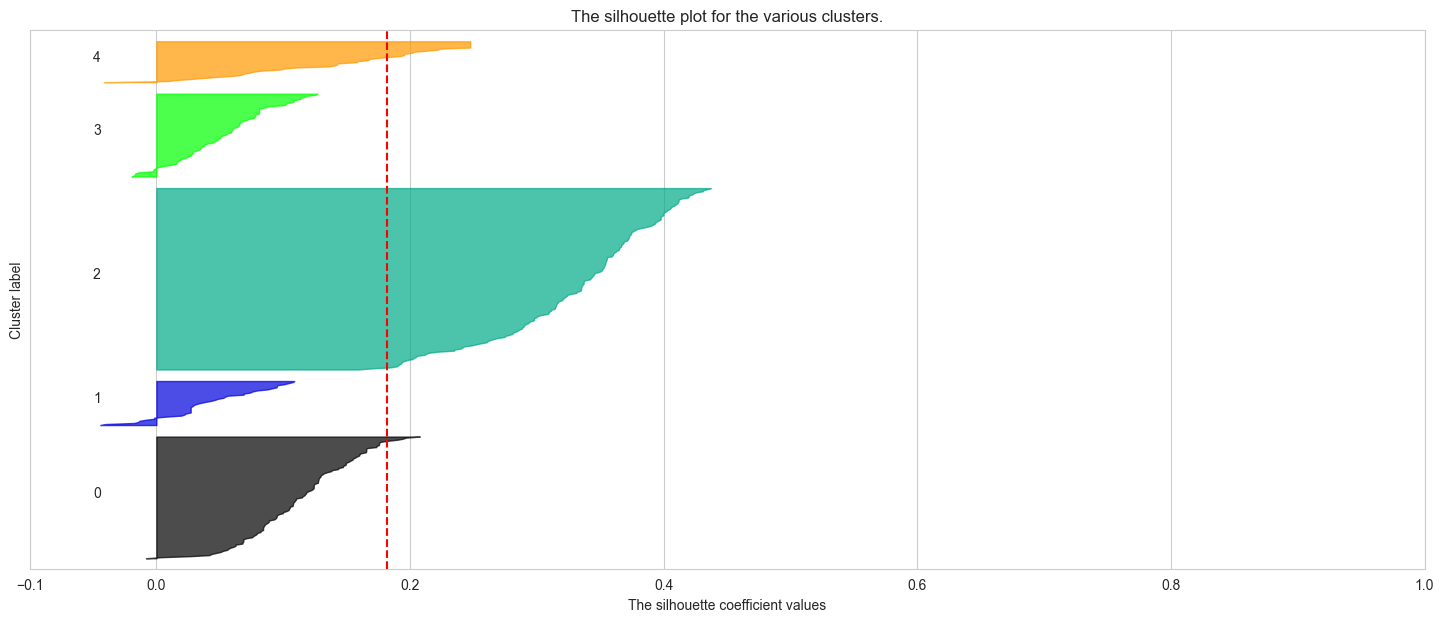

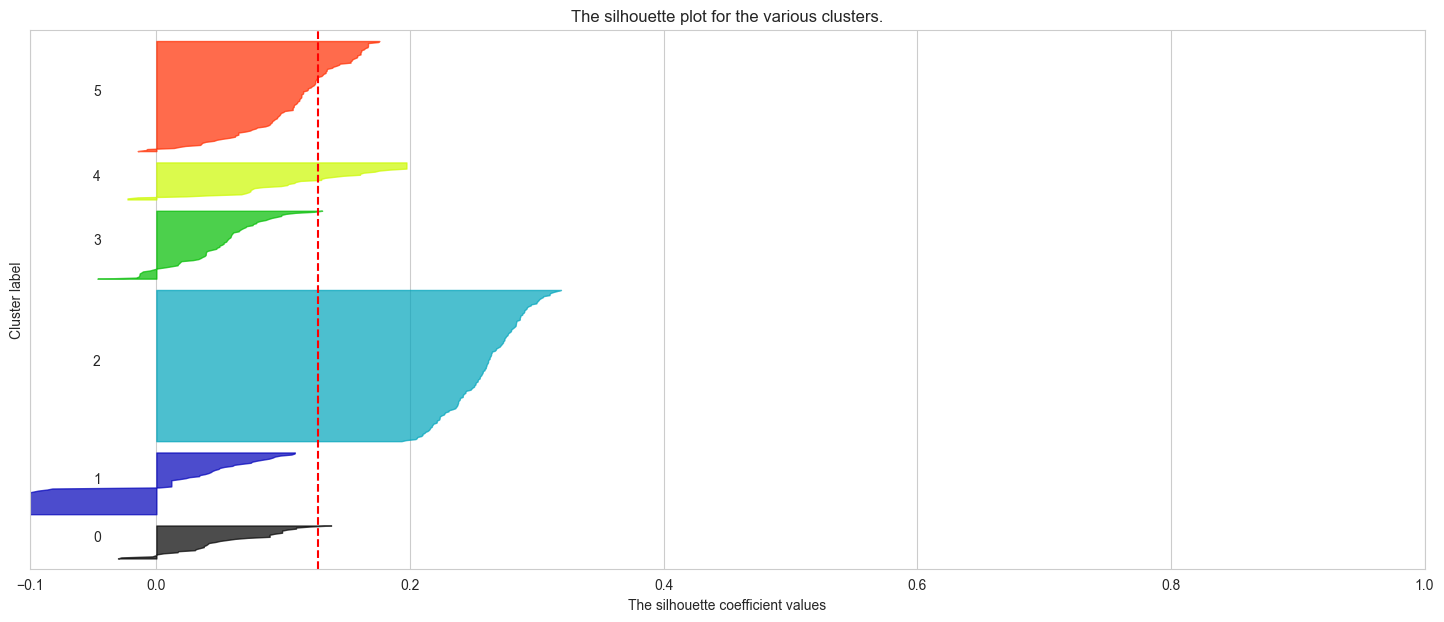

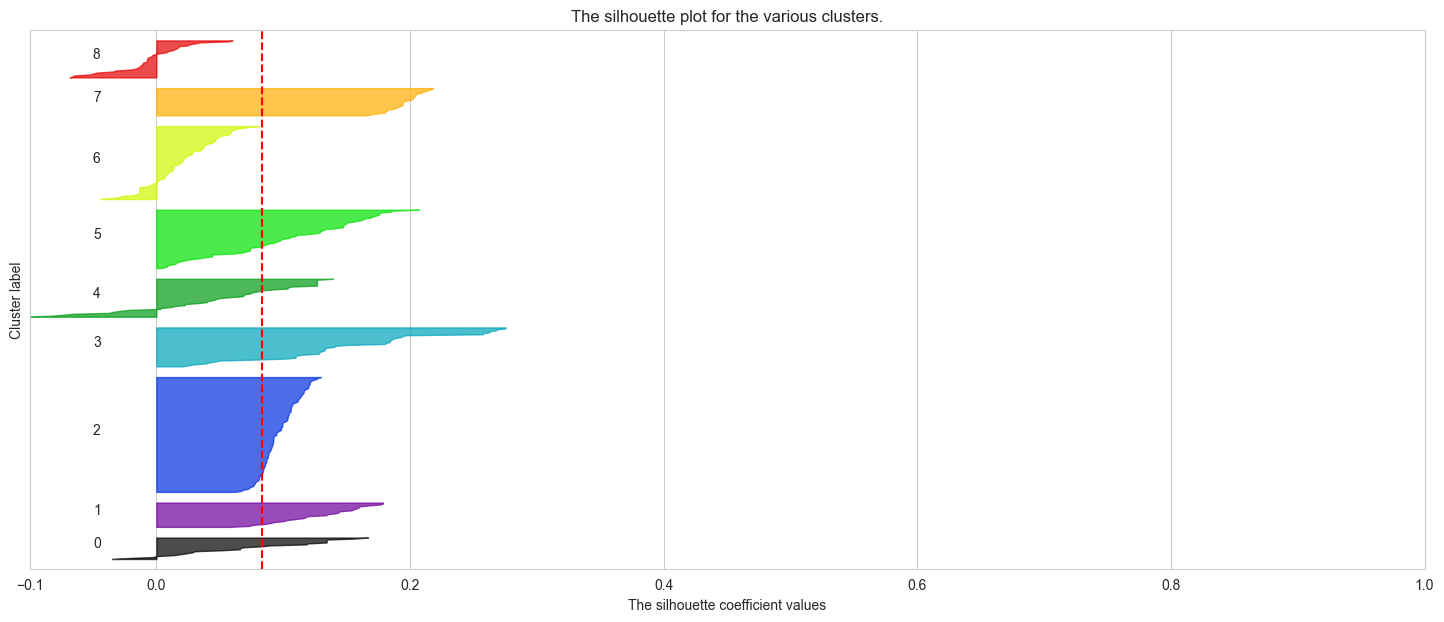

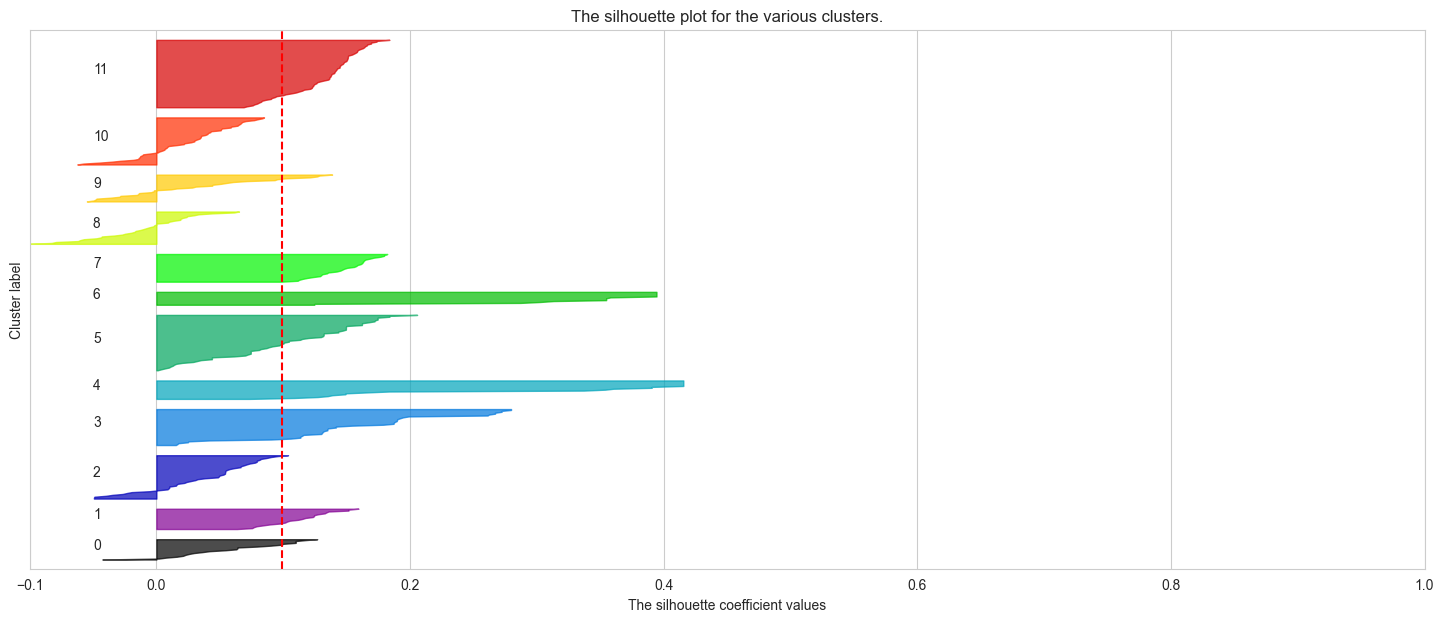

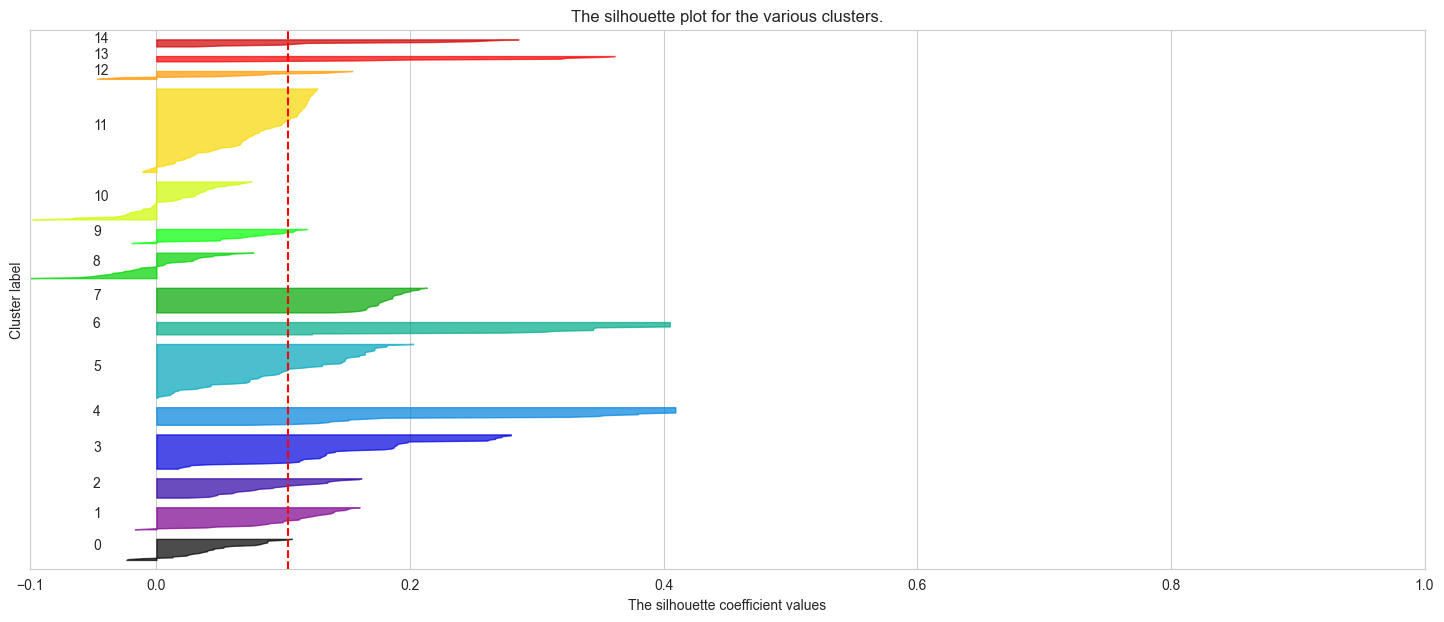

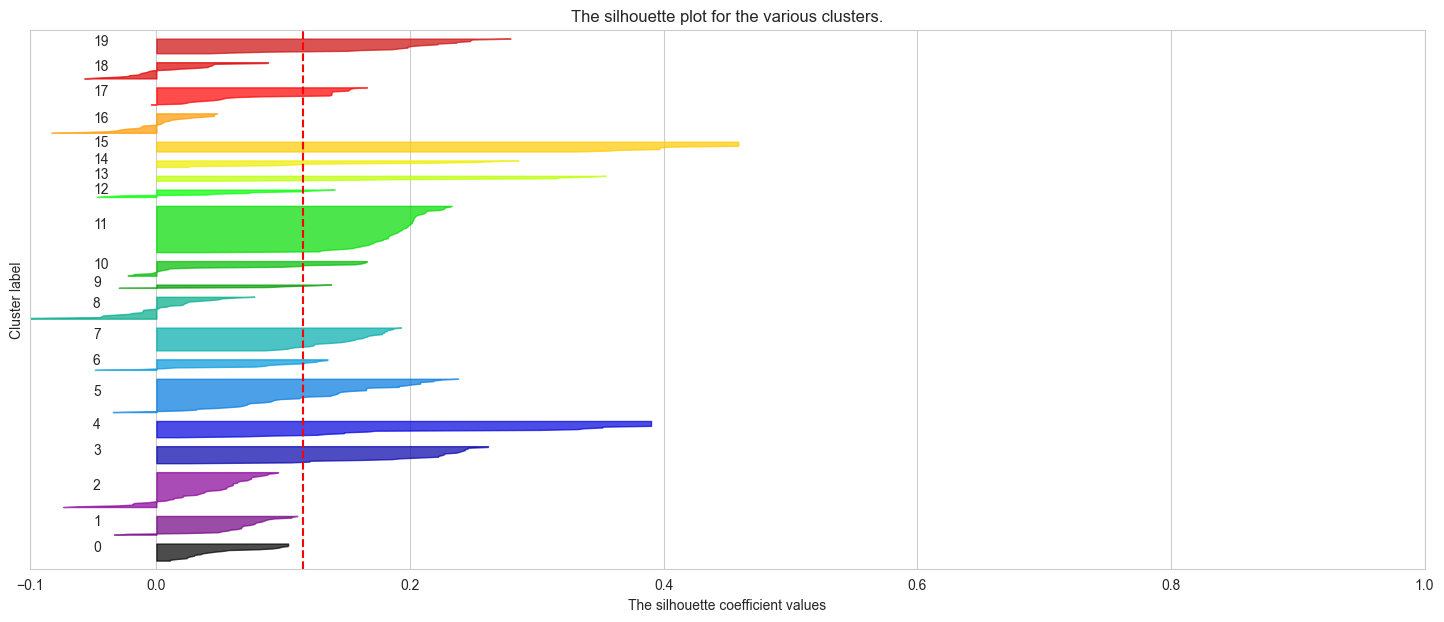

In [61]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
# X, y = make_blobs(
#     n_samples=500,
#     n_features=2,
#     centers=4,
#     cluster_std=1,
#     center_box=(-10.0, 10.0),
#     shuffle=True,
#     random_state=1,
# )  # For reproducibility

X = encoded_df

range_n_clusters = [5, 6, 9, 12, 15, 20]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    # colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    # ax2.scatter(
    #     X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    # )
    #
    # # Labeling the clusters
    # centers = clusterer.cluster_centers_
    # # Draw white circles at cluster centers
    # ax2.scatter(
    #     centers[:, 0],
    #     centers[:, 1],
    #     marker="o",
    #     c="white",
    #     alpha=1,
    #     s=200,
    #     edgecolor="k",
    # )
    #
    # for i, c in enumerate(centers):
    #     ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")
    #
    # ax2.set_title("The visualization of the clustered data.")
    # ax2.set_xlabel("Feature space for the 1st feature")
    # ax2.set_ylabel("Feature space for the 2nd feature")
    #
    # plt.suptitle(
    #     "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
    #     % n_clusters,
    #     fontsize=14,
    #     fontweight="bold",
    # )

plt.show()

On remarque que les meilleurs choix sont le 5 pour son score et le 12 pour sa silouhette, nous allons tenter les 2.

In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(encoded_df)

X_train['cluster'] = kmeans.labels_

Prediction d'un titre:

In [117]:
from sklearn.metrics.pairwise import cosine_similarity

def filter_info(new_X):
    new_X_encoded_data = encoder.transform(new_X[column_to_encode])
    new_X_encoded_df_no_description = pd.DataFrame(
        new_X_encoded_data.toarray(),
    columns=encoder.get_feature_names_out(column_to_encode),
    index=new_X.index
    )

    new_X_description = model.encode(new_X['Description'].fillna('').tolist())
    new_X_description_df = pd.DataFrame(new_X_description, index=new_X.index)

    new_X_encoded_df = pd.concat(
    [new_X.drop(columns=column_to_encode).drop(['Description'], axis=1), new_X_encoded_df_no_description, new_X_description_df],
    axis=1
    )

    new_X_encoded_df.columns = new_X_encoded_df.columns.astype(str)

    return new_X_encoded_df

def get_title_new_value(new_X):

    new_X_encoded_df = filter_info(new_X)

    cluster_predit = kmeans.predict(new_X_encoded_df)[0]

    X_cluster = filter_info(X_train[X_train['cluster'] == cluster_predit])
    X_cluster.drop('cluster', axis=1, inplace=True)
    indices = X_cluster.index

    similarities = cosine_similarity(new_X_encoded_df, X_cluster)

    index_plus_proche_local = similarities.argmax()
    index_global = indices[index_plus_proche_local]

    titre_attribue = df.loc[index_global]['Titre ANSSI']
    return titre_attribue

In [120]:
test = X_test.head(1).drop('Titre ANSSI', axis=1)
titre_originel = X_test.head(1)['Titre ANSSI']
test

,Type,CVE,CVSS,CWE,EPSS,Description,Editeur,Produit
1277,Avis,CVE-2026-26996,8.7,CWE-1333,0.00026,minimatch is a minimal matching utility for co...,isaacs,minimatch


In [121]:
get_title_new_value(test)

'Multiples vulnérabilités dans les produits IBM'

In [122]:
titre_originel

1277    Multiples vulnérabilités dans les produits IBM
Name: Titre ANSSI, dtype: str